In [1]:
# Cell 1: Install Libraries
%pip install seaborn scikit-learn matplotlib joblib

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Cell 2: Load Data
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

try:
    df = pd.read_csv('data/raw/master_dataset_real.csv')
    print(f"✅ Loaded {len(df)} rows.")
except FileNotFoundError:
    print("❌ Data file not found.")

✅ Loaded 3056 rows.


In [3]:
# Cell 3: Feature Engineering
# Handle Dates
df['acq_date'] = pd.to_datetime(df['acq_date'])
df['month'] = df['acq_date'].dt.month

# Handle Time (Safely)
if 'acq_time' in df.columns:
    df['acq_time'] = df['acq_time'].fillna(0).astype(int)
    df['hour'] = df['acq_time'] // 100
    df['is_day'] = df['hour'].apply(lambda x: 1 if 6 <= x <= 18 else 0)
    drop_cols = ['acq_date', 'acq_time', 'dt_utc', 'frp']
else:
    drop_cols = ['acq_date', 'dt_utc', 'frp']

# Drop columns
df_clean = df.drop(columns=[c for c in drop_cols if c in df.columns])
print(f"Features: {list(df_clean.columns)}")

Features: ['latitude', 'longitude', 'fire_detected', 'time', 'interval', 'temperature_2m', 'relative_humidity_2m', 'wind_speed_10m', 'soil_moisture_0_to_7cm', 'month']


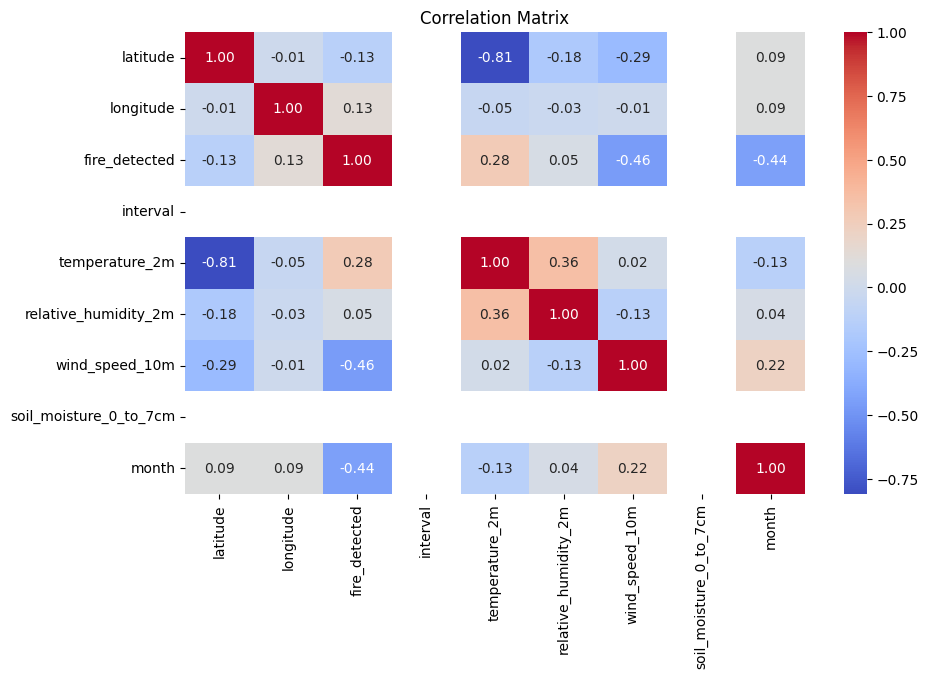

In [4]:
# Cell 4: Physics Check
plt.figure(figsize=(10, 6))
sns.heatmap(df_clean.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [5]:
# Cell 5: Impute, Split, Scale, Save
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import joblib

# 1. Define X and y
X = df_clean.drop('fire_detected', axis=1).select_dtypes(include=[np.number])
y = df_clean['fire_detected']

# 2. Drop Empty Columns (Fixes the shape error)
X = X.dropna(axis=1, how='all')

# 3. Impute Missing Values (Safety Net)
imputer = SimpleImputer(strategy='mean')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

# 4. Save Feature Names (Crucial for later)
joblib.dump(list(X.columns), 'data/processed/feature_names.pkl')

# 5. Split (Stratified)
X_train, X_test, y_train, y_test = train_test_split(X_imputed, y, test_size=0.2, stratify=y, random_state=42)

# 6. Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 7. Save Everything
np.save('data/processed/X_train.npy', X_train_scaled)
np.save('data/processed/X_test.npy', X_test_scaled)
np.save('data/processed/y_train.npy', y_train)
np.save('data/processed/y_test.npy', y_test)
joblib.dump(scaler, 'data/processed/scaler.pkl')
joblib.dump(imputer, 'data/processed/imputer.pkl')

print("✅ Phase 2 Complete. Files saved to data/processed/")

✅ Phase 2 Complete. Files saved to data/processed/


In [6]:
# Cell 6: Advanced Preprocessing (Feature Names & SMOTE Check)
import joblib
import pandas as pd
import numpy as np

# 1. SAVE FEATURE NAMES (Critical for Phase 4)
# We need to know which column is which for the final report
feature_names = X_imputed.columns.tolist()
joblib.dump(feature_names, 'data/processed/feature_names.pkl')
print(f"✅ Feature names saved: {feature_names}")

# 2. CHECK IMBALANCE & SUGGEST SMOTE
# Count how many fires we actually have in the training set
unique, counts = np.unique(y_train, return_counts=True)
dist = dict(zip(unique, counts))
fire_ratio = dist[1] / (dist[0] + dist[1])

print(f"\n--- Imbalance Check ---")
print(f"Safe Zones: {dist[0]}")
print(f"Fires:      {dist[1]}")
print(f"Fire Ratio: {fire_ratio:.2%}")

if fire_ratio < 0.15: # If fires are less than 15% of data
    print("⚠️ WARNING: Severe Class Imbalance detected!")
    print("Recommendation: You should use SMOTE to balance the dataset.")
else:
    print("✅ Class balance is acceptable. No SMOTE needed.")

✅ Feature names saved: ['latitude', 'longitude', 'interval', 'temperature_2m', 'relative_humidity_2m', 'wind_speed_10m', 'month']

--- Imbalance Check ---
Safe Zones: 1182
Fires:      1262
Fire Ratio: 51.64%
✅ Class balance is acceptable. No SMOTE needed.
